# Assignment 3: Jet Generation Challenge

This notebook implements a **conditional flow-matching** model for JetNet jet generation and is organized to directly match the assignment tasks in `assignment-03.txt`.

**Dataset:** JetNet (5 jet types: `g, q, t, w, z`), each jet as a masked particle set with up to 30 particles and features $(\eta_{rel}, \phi_{rel}, p_T^{rel})$.

**Objective:** Minimize the composite validation **W1 score** (sum across 5 jet types × 4 observables: mass, $\eta$, $\phi$, $p_T$). Lower is better.

**What this notebook covers:**
1. Baseline understanding + data/physics visualization.
2. JetNet-tailored architecture and training improvements.
3. Quantitative and qualitative evaluation.
4. Submission artifact generation (`submission.npz`, `model_params.pkl`) compatible with `generate.py`.

In [1]:
import os
import sys
import time
import urllib.request

import flax.linen as nn
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax


def _ensure_utils_importable():
    """Make `utils.py` importable in Colab/local, with GitHub fallback."""
    if os.path.exists("utils.py"):
        return

    candidates = [
        os.path.join(os.getcwd(), "code"),
        "/content/assignment-3-LeoMattosMartins/code",
        "/content/drive/MyDrive/assignment-3-LeoMattosMartins/code",
        "/content/drive/MyDrive/geonosis/assignment-3-LeoMattosMartins/code",
    ]

    for path in candidates:
        utils_path = os.path.join(path, "utils.py")
        if os.path.exists(utils_path):
            if path not in sys.path:
                sys.path.insert(0, path)
            os.chdir(path)
            print(f"Using repo code directory: {path}")
            return

    # Direct fallback: fetch utils.py from lab starter repo
    raw_url = "https://raw.githubusercontent.com/bu-ds595/assignment03-starter/main/code/utils.py"

    try:
        urllib.request.urlretrieve(raw_url, "utils.py")
        print(f"Downloaded utils.py from: {raw_url}")
        return
    except Exception:
        pass

    raise FileNotFoundError("Could not locate or download utils.py")

_ensure_utils_importable()

from utils import (
    JET_NAMES,
    JET_TYPES,
    N_FEATURES,
    N_PARTICLES,
    N_TYPES,
    compute_jet_mass,
    save_model,
    save_submission,
    sinusoidal_embedding,
)

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["font.size"] = 12

print(f"Working directory: {os.getcwd()}")
print(f"JAX backend: {jax.default_backend()}")
print(f"Local device count: {jax.local_device_count()}")
print(f"JAX devices: {jax.devices()}")

# Colab TPU: Runtime -> Change runtime type -> TPU, then run cells in order.

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Working directory: /content
JAX backend: tpu
Local device count: 1
JAX devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


---
## 1. Data Loading, Exploration, and Baseline Diagnosis

The assignment asks you to first understand where the baseline fails. Use this section to:

- Load train/validation splits and verify shapes and masks.
- Inspect per-type jet structure in $(\eta,\phi)$ scatter plots.
- Compare mass and particle-level marginals.

**Question to answer in your report:** Where does the baseline fail?
- Typical failure mode: a flat model underfits multi-prong substructure (especially `t`, `w`, `z`) and tends to blur high-$p_T$ structure.
- Look for this as larger W1 gaps in mass and tails of $p_T$ / angular marginals.

In [2]:
# Download data if not already present
import os, urllib.request

DATA_DIR = "data"
BASE_URL = "https://github.com/bu-ds595/assignment03-starter/releases/download/v1.0"
for fname in ["train.npz", "val.npz"]:
    dest = os.path.join(DATA_DIR, fname)
    if not os.path.exists(dest):
        os.makedirs(DATA_DIR, exist_ok=True)
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(f"{BASE_URL}/{fname}", dest)
        print(f"  Saved {dest} ({os.path.getsize(dest) / 1e6:.1f} MB)")

# Load pre-split data
train_npz = np.load("data/train.npz")
val_npz = np.load("data/val.npz")

# Per-type arrays for evaluation and visualization
train_data = {jt: train_npz[f"{jt}_jets"] for jt in JET_TYPES}
train_masks = {jt: train_npz[f"{jt}_masks"] for jt in JET_TYPES}
val_data = {jt: val_npz[f"{jt}_jets"] for jt in JET_TYPES}
val_masks = {jt: val_npz[f"{jt}_masks"] for jt in JET_TYPES}

for jt in JET_TYPES:
    print(f"{JET_NAMES[jt]:>8}: train {train_data[jt].shape[0]:,} | val {val_data[jt].shape[0]:,}")

print(f"\nFeatures per particle: eta_rel, phi_rel, pt_rel")
print(f"Particle shape: (N, {N_PARTICLES}, {N_FEATURES})  |  Mask shape: (N, {N_PARTICLES})")

   Gluon: train 124,076 | val 26,587
   Quark: train 119,475 | val 25,601
     Top: train 124,561 | val 26,691
 W boson: train 124,020 | val 26,575
 Z boson: train 123,866 | val 26,542

Features per particle: eta_rel, phi_rel, pt_rel
Particle shape: (N, 30, 3)  |  Mask shape: (N, 30)


In [3]:
# Combined arrays for training
X_train = train_npz["jets"]
y_train = train_npz["labels"]
masks_train = train_npz["masks"]

# Shuffle
rng = np.random.default_rng(42)
shuffle_idx = rng.permutation(len(X_train))
X_train = X_train[shuffle_idx]
y_train = y_train[shuffle_idx]
masks_train = masks_train[shuffle_idx]

print(f"Combined training set: {X_train.shape}")
print(f"Jet type distribution: {dict(zip(JET_TYPES, [int((y_train == i).sum()) for i in range(N_TYPES)]))}")

Combined training set: (615998, 30, 3)
Jet type distribution: {'g': 124076, 'q': 119475, 't': 124561, 'w': 124020, 'z': 123866}


### Visualize jets in the $\eta$-$\phi$ plane

Each jet is a masked particle cloud. Marker size is proportional to $p_T^{rel}$.

Use these plots to support analysis required in the assignment:
- `t` jets should show roughly three-prong structure.
- `w`/`z` jets should show two-prong structure.
- `g`/`q` jets are generally more diffuse single-prong patterns.

If generated jets later look too smooth or lose these prong patterns, that indicates architectural or training mismatch.

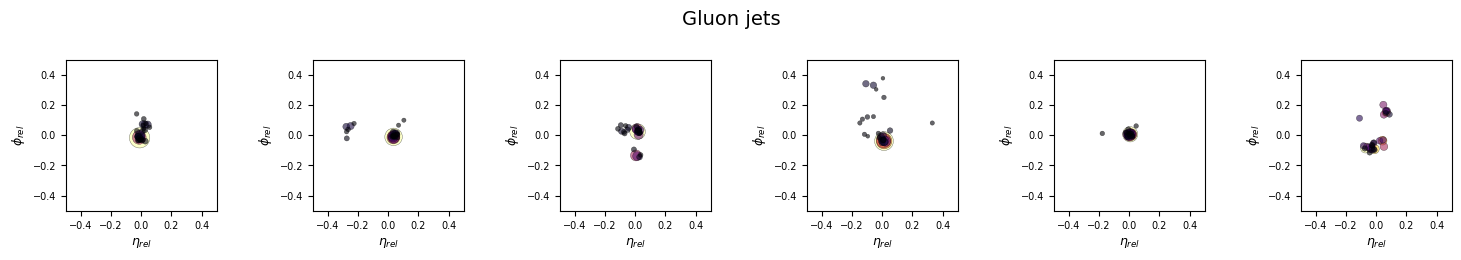

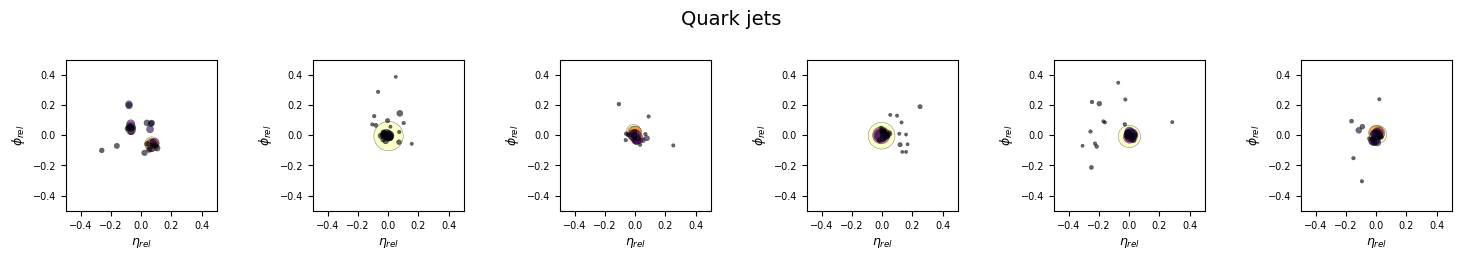

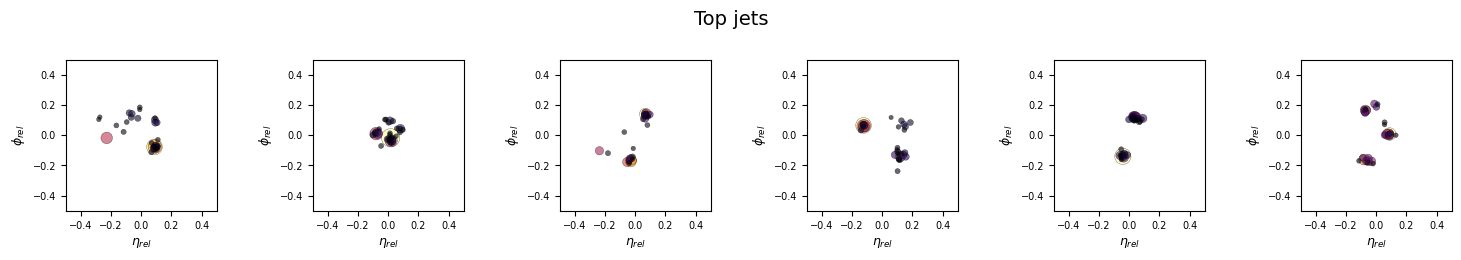

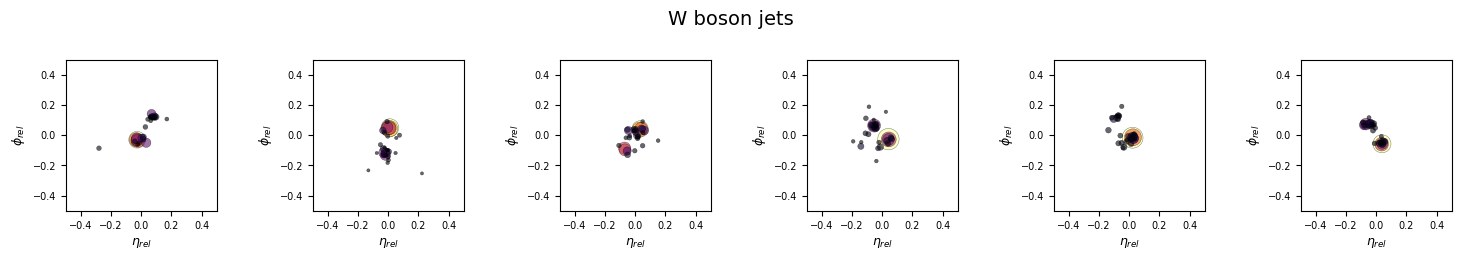

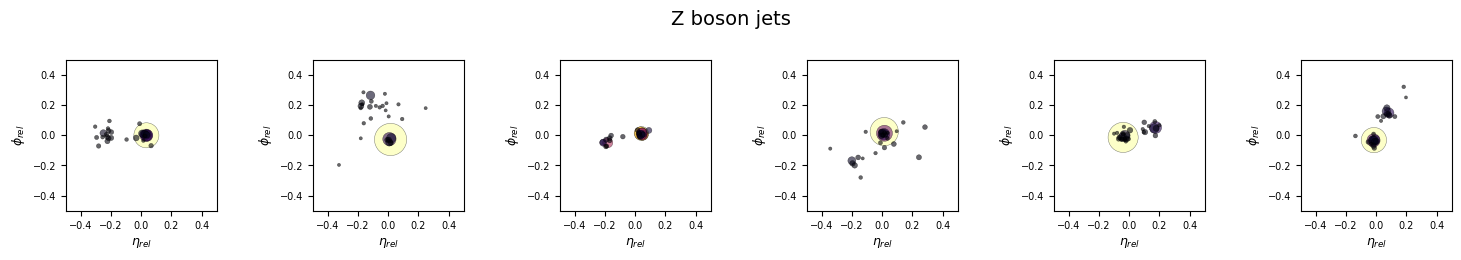

In [4]:
def plot_eta_phi(jets, masks, title="", n_jets=6, ncols=6):
    """Scatter plot of jets in the (eta, phi) plane with pt-sized markers."""
    nrows = (n_jets + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.flat):
        if i >= n_jets:
            ax.axis("off")
            continue
        m = masks[i] > 0.5
        eta, phi, pt = jets[i, m, 0], jets[i, m, 1], jets[i, m, 2]
        sizes = 800 * np.clip(pt, 0, None) + 5
        ax.scatter(eta, phi, s=sizes, alpha=0.6, c=pt, cmap="inferno", edgecolors="k", linewidths=0.3)
        ax.set_xlim(-0.5, 0.5)
        ax.set_ylim(-0.5, 0.5)
        ax.set_aspect("equal")
        ax.set_xlabel("$\\eta_{rel}$", fontsize=9)
        ax.set_ylabel("$\\phi_{rel}$", fontsize=9)
        ax.tick_params(labelsize=7)
    if title:
        plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# Show 6 examples per jet type
for jt in JET_TYPES:
    idx = np.random.choice(len(train_data[jt]), 6, replace=False)
    plot_eta_phi(train_data[jt][idx], train_masks[jt][idx], title=f"{JET_NAMES[jt]} jets")

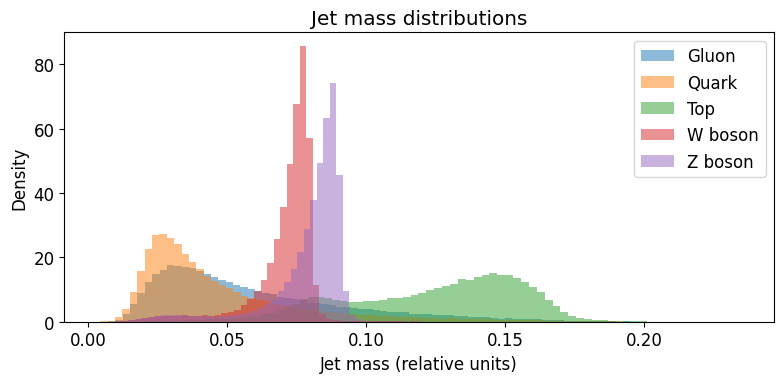

In [5]:
# Jet mass distributions per type
fig, ax = plt.subplots(figsize=(8, 4))
for jt in JET_TYPES:
    masses = compute_jet_mass(train_data[jt], train_masks[jt])
    ax.hist(masses, bins=80, alpha=0.5, density=True, label=JET_NAMES[jt])
ax.set(xlabel="Jet mass (relative units)", ylabel="Density", title="Jet mass distributions")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. JetNet-Tailored Flow Matching Model

This section implements the core assignment improvement beyond the baseline.

### What changed from the starter baseline (and why)
1. **Set-aware architecture**: masked self-attention over particles instead of a simple flat MLP.
2. **Physics-informed particle features**: add `log(1 + p_T)` and radial distance in the $(\eta,\phi)$ plane.
3. **Stronger conditioning**: FiLM-style modulation with time and jet-type embeddings at multiple depths.
4. **Training stabilizers**: AdamW schedule, EMA, clipping, mask-aware weighted objective.
5. **Better sampler**: RK2/Heun integration for lower discretization error.

These choices target lower W1, especially on mass and high-$p_T$ regions, while respecting masked variable-length particle sets.

In [6]:
class ParticleSetVelocity(nn.Module):
    """JetNet-tailored conditional velocity model (set attention + FiLM conditioning)."""

    hidden_dim: int = 256
    n_blocks: int = 4
    n_heads: int = 4
    ff_mult: int = 2
    n_types: int = N_TYPES
    time_dim: int = 96

    @nn.compact
    def __call__(self, x_t, t, y, mask, train=False):
        B, N, _ = x_t.shape
        m = mask[:, :, None]

        te = sinusoidal_embedding(t, self.time_dim)
        te = nn.silu(nn.Dense(self.hidden_dim)(te))
        y_emb = nn.Embed(num_embeddings=self.n_types, features=self.hidden_dim)(y)
        cond = nn.LayerNorm()(te + y_emb)

        pt = x_t[:, :, 2:3]
        log_pt = jnp.log1p(jnp.clip(pt, a_min=0.0))
        r = jnp.sqrt(jnp.sum(x_t[:, :, :2] ** 2, axis=-1, keepdims=True) + 1e-8)
        h = jnp.concatenate([x_t, log_pt, r], axis=-1)
        h = nn.silu(nn.Dense(self.hidden_dim)(h))

        film0 = nn.Dense(2 * self.hidden_dim)(cond)
        gamma0, beta0 = jnp.split(film0, 2, axis=-1)
        h = (1.0 + gamma0[:, None, :]) * h + beta0[:, None, :]
        h = h * m

        attn_mask = (mask > 0.5)[:, None, None, :]

        for _ in range(self.n_blocks):
            h_in = h
            attn_out = nn.MultiHeadDotProductAttention(
                num_heads=self.n_heads,
                qkv_features=self.hidden_dim,
                out_features=self.hidden_dim,
                dropout_rate=0.0,
            )(h, h, mask=attn_mask, deterministic=not train)
            h = nn.LayerNorm()(h_in + attn_out)

            ff = nn.Dense(self.hidden_dim * self.ff_mult)(h)
            ff = nn.gelu(ff)
            ff = nn.Dense(self.hidden_dim)(ff)

            film = nn.Dense(2 * self.hidden_dim)(cond)
            gamma, beta = jnp.split(film, 2, axis=-1)
            h = nn.LayerNorm()(h + (1.0 + gamma[:, None, :]) * ff + beta[:, None, :])
            h = h * m

            denom = jnp.clip(mask.sum(axis=1, keepdims=True), a_min=1.0)
            g = h.sum(axis=1) / denom
            g = nn.silu(nn.Dense(self.hidden_dim)(jnp.concatenate([g, cond], axis=-1)))
            h = (h + g[:, None, :]) * m

        denom = jnp.clip(mask.sum(axis=1, keepdims=True), a_min=1.0)
        global_feat = h.sum(axis=1) / denom

        globalN = jnp.broadcast_to(global_feat[:, None, :], (B, N, self.hidden_dim))
        condN = jnp.broadcast_to(cond[:, None, :], (B, N, self.hidden_dim))
        out_in = jnp.concatenate([h, globalN, condN], axis=-1)

        out = nn.silu(nn.Dense(2 * self.hidden_dim)(out_in))
        out = nn.silu(nn.Dense(self.hidden_dim)(out))
        v = nn.Dense(N_FEATURES)(out)
        return v * m


model = ParticleSetVelocity()
dummy_params = model.init(
    jr.PRNGKey(0),
    jnp.ones((2, 30, 3), dtype=jnp.float32),
    jnp.array([0.5, 0.5], dtype=jnp.float32),
    jnp.zeros(2, dtype=jnp.int32),
    jnp.ones((2, 30), dtype=jnp.float32),
)
n_params = sum(p.size for p in jax.tree.leaves(dummy_params))
print(f"ParticleSetVelocity (JetNet): {n_params:,} params")

ParticleSetVelocity (JetNet): 3,845,635 params


In [7]:
def train_fm(
    model,
    X,
    y,
    masks,
    n_epochs=10,
    batch_size=1024,
    lr=2e-4,
    seed=0,
    ema_decay=0.9995,
    clip_norm=1.0,
):
    """TPU-efficient conditional flow matching training."""
    key = jr.PRNGKey(seed)
    key, init_key = jr.split(key)

    X_jax = jax.device_put(jnp.array(X, dtype=jnp.float32))
    y_jax = jax.device_put(jnp.array(y, dtype=jnp.int32))
    m_jax = jax.device_put(jnp.array(masks, dtype=jnp.float32))

    params = model.init(
        init_key,
        X_jax[:1],
        jnp.array([0.5], dtype=jnp.float32),
        y_jax[:1],
        m_jax[:1],
    )

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=lr,
        warmup_steps=400,
        decay_steps=8000,
        end_value=0.25 * lr,
    )
    optimizer = optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adamw(learning_rate=schedule, b1=0.9, b2=0.95, weight_decay=1e-4),
    )
    opt_state = optimizer.init(params)
    ema_params = params

    def loss_fn(params, x1, y_batch, mask_batch, key):
        B = x1.shape[0]
        k1, k2, k3 = jr.split(key, 3)

        x0 = jr.normal(k1, x1.shape) * mask_batch[:, :, None]

        mix = jr.uniform(k2, shape=(B,))
        t_beta = jr.beta(k3, a=0.7, b=0.7, shape=(B,))
        t = jnp.where(mix < 0.7, t_beta, jr.uniform(k2, shape=(B,)))
        t = jnp.clip(t, 1e-5, 1.0 - 1e-5)
        t4 = t[:, None, None]

        x_t = (1 - t4) * x0 + t4 * x1
        target = x1 - x0
        pred = model.apply(params, x_t, t, y_batch, mask_batch, train=True)

        sq = (pred - target) ** 2
        pt_weight = 1.0 + 1.5 * jnp.clip(x1[:, :, 2], a_min=0.0)
        sq = sq * pt_weight[:, :, None] * mask_batch[:, :, None]

        denom = jnp.clip((mask_batch * pt_weight).sum() * N_FEATURES, a_min=1.0)
        return sq.sum() / denom

    @jax.jit
    def step(params, ema_params, opt_state, x1, y_batch, mask_batch, key):
        loss, grads = jax.value_and_grad(loss_fn)(params, x1, y_batch, mask_batch, key)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        new_ema_params = jax.tree_util.tree_map(
            lambda e, p: ema_decay * e + (1.0 - ema_decay) * p,
            ema_params,
            new_params,
        )
        return new_params, new_ema_params, new_opt_state, loss

    batch_rng = np.random.default_rng(seed)
    history = []
    epoch_times = []

    n_samples = len(X_jax)
    for epoch in range(n_epochs):
        ep_start = time.time()
        idx = batch_rng.permutation(n_samples)
        ep_losses = []

        for start in range(0, n_samples, batch_size):
            bi = idx[start : start + batch_size]
            key, sk = jr.split(key)
            params, ema_params, opt_state, loss = step(
                params,
                ema_params,
                opt_state,
                X_jax[bi],
                y_jax[bi],
                m_jax[bi],
                sk,
            )
            ep_losses.append(float(loss))

        avg_loss = float(np.mean(ep_losses))
        history.append(avg_loss)

        epoch_sec = time.time() - ep_start
        epoch_times.append(epoch_sec)

        if (epoch + 1) % 5 == 0:
            mean_epoch_sec = float(np.mean(epoch_times))
            print(
                f"Epoch {epoch + 1:3d}/{n_epochs} | "
                f"loss {avg_loss:.5f} | "
                f"epoch {epoch_sec:.2f}s | "
                f"avg/epoch {mean_epoch_sec:.2f}s"
            )

    return ema_params, history

Epoch   5/200 | loss 0.17466 | epoch 7.93s | avg/epoch 28.30s
Epoch  10/200 | loss 0.17087 | epoch 8.13s | avg/epoch 18.18s
Epoch  15/200 | loss 0.16922 | epoch 7.84s | avg/epoch 14.80s
Epoch  20/200 | loss 0.17006 | epoch 8.11s | avg/epoch 13.13s
Epoch  25/200 | loss 0.16925 | epoch 8.15s | avg/epoch 12.12s
Epoch  30/200 | loss 0.16888 | epoch 8.06s | avg/epoch 11.44s
Epoch  35/200 | loss 0.16945 | epoch 8.14s | avg/epoch 10.95s
Epoch  40/200 | loss 0.16886 | epoch 8.10s | avg/epoch 10.60s
Epoch  45/200 | loss 0.16878 | epoch 8.30s | avg/epoch 10.33s
Epoch  50/200 | loss 0.16912 | epoch 8.25s | avg/epoch 10.11s
Epoch  55/200 | loss 0.16839 | epoch 8.13s | avg/epoch 9.93s
Epoch  60/200 | loss 0.16847 | epoch 8.05s | avg/epoch 9.78s
Epoch  65/200 | loss 0.16873 | epoch 8.10s | avg/epoch 9.65s
Epoch  70/200 | loss 0.16846 | epoch 8.12s | avg/epoch 9.54s
Epoch  75/200 | loss 0.16835 | epoch 8.14s | avg/epoch 9.44s
Epoch  80/200 | loss 0.16814 | epoch 8.12s | avg/epoch 9.36s
Epoch  85/200 

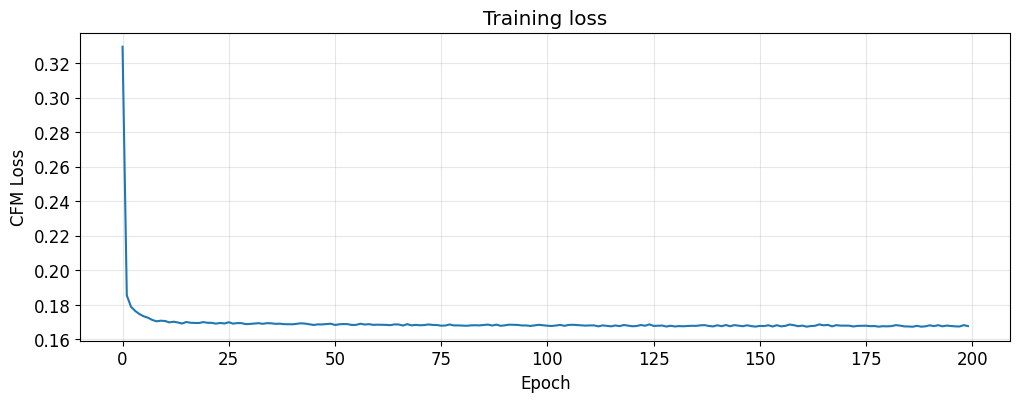

In [9]:
# Train the JetNet-tailored model
model = ParticleSetVelocity()
params, history = train_fm(
    model,
    X_train,
    y_train,
    masks_train,
    n_epochs=200,
    batch_size=1024,
    lr=2e-4,
    ema_decay=0.9995,
    clip_norm=1.0,
)

plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("CFM Loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

---
## 3. Sampling, Evaluation, and Analysis

Assignment requirement: evaluate rigorously with both quantitative and qualitative checks.

In this section:
- Generate jets per type from the trained conditional model.
- Compute full composite W1 and per-type/per-observable breakdown.
- Plot distribution overlays and $(\eta,\phi)$ side-by-side real vs generated.

**Questions to answer in your report:**
- Which jet types are hardest?
- Which observables (mass, $\eta$, $\phi$, $p_T$) dominate error?
- What improved after each model/training change?

In [10]:
def sample_jets(model, params, jet_type_idx, masks_ref, key, n_samples=2000, steps=64):
    """Generate jets via 2nd-order (Heun / RK2) integration."""
    dt = 1.0 / steps
    k1, k2 = jr.split(key)

    mask_idx = jr.randint(k1, (n_samples,), 0, masks_ref.shape[0])
    masks = jnp.array(masks_ref[np.array(mask_idx)], dtype=jnp.float32)

    x = jr.normal(k2, (n_samples, N_PARTICLES, N_FEATURES), dtype=jnp.float32) * masks[:, :, None]
    y = jnp.full((n_samples,), jet_type_idx, dtype=jnp.int32)

    @jax.jit
    def rk2_step(x, i):
        t = jnp.full((n_samples,), i * dt, dtype=jnp.float32)
        v1 = model.apply(params, x, t, y, masks, train=False)

        x_pred = x + dt * v1
        t2 = jnp.full((n_samples,), (i + 1) * dt, dtype=jnp.float32)
        v2 = model.apply(params, x_pred, t2, y, masks, train=False)

        return x + dt * 0.5 * (v1 + v2)

    for i in range(steps):
        x = rk2_step(x, i)

    x = x * masks[:, :, None]
    x = x.at[:, :, 2].set(jnp.clip(x[:, :, 2], a_min=0.0))
    return np.array(x), np.array(masks)

In [11]:
def compute_w1_score(gen_jets_dict, gen_masks_dict, real_jets_dict, real_masks_dict):
    """Compute composite W1 score (the leaderboard metric)."""
    from scipy.stats import wasserstein_distance

    results = {}
    total = 0.0
    for jt in JET_TYPES:
        gen, gen_m = gen_jets_dict[jt], gen_masks_dict[jt]
        real, real_m = real_jets_dict[jt], real_masks_dict[jt]
        scores = {}
        scores["mass"] = wasserstein_distance(compute_jet_mass(gen, gen_m), compute_jet_mass(real, real_m))
        for f_idx, fname in enumerate(["eta", "phi", "pt"]):
            scores[fname] = wasserstein_distance(gen[:, :, f_idx][gen_m > 0.5], real[:, :, f_idx][real_m > 0.5])
        results[jt] = scores
        total += sum(scores.values())
    return total, results


def print_scores(total, results):
    """Pretty-print the W1 score breakdown."""
    print(f"{'Type':>6} | {'Mass':>8} | {'eta':>8} | {'phi':>8} | {'pt':>8} | {'Total':>8}")
    print("-" * 60)
    for jt in JET_TYPES:
        s = results[jt]
        row_total = sum(s.values())
        print(f"{jt:>6} | {s['mass']:8.5f} | {s['eta']:8.5f} | {s['phi']:8.5f} | {s['pt']:8.5f} | {row_total:8.5f}")
    print("-" * 60)
    print(f"{'TOTAL':>6} | {'':>8} | {'':>8} | {'':>8} | {'':>8} | {total:8.5f}")
    print(f"\nLeaderboard score: {total:.5f} (lower is better)")

In [12]:
# Generate jets for each type
# If ablation harness was run, use selected sampler steps; otherwise default to 64.
sample_steps = int(globals().get("best_sample_steps", 64))
print(f"Using sample_steps={sample_steps}")

gen_jets, gen_masks = {}, {}
for i, jt in enumerate(JET_TYPES):
    print(f"Generating {JET_NAMES[jt]} jets...")
    gen_jets[jt], gen_masks[jt] = sample_jets(
        model,
        params,
        i,
        train_masks[jt],
        jr.PRNGKey(i),
        n_samples=2000,
        steps=sample_steps,
    )

total, results = compute_w1_score(gen_jets, gen_masks, val_data, val_masks)
print_scores(total, results)

Using sample_steps=64
Generating Gluon jets...
Generating Quark jets...
Generating Top jets...
Generating W boson jets...
Generating Z boson jets...
  Type |     Mass |      eta |      phi |       pt |    Total
------------------------------------------------------------
     g |  0.00092 |  0.00136 |  0.00162 |  0.00231 |  0.00621
     q |  0.00604 |  0.00152 |  0.00181 |  0.00231 |  0.01169
     t |  0.00175 |  0.00115 |  0.00147 |  0.00205 |  0.00641
     w |  0.00368 |  0.00119 |  0.00075 |  0.00177 |  0.00739
     z |  0.00364 |  0.00050 |  0.00046 |  0.00189 |  0.00649
------------------------------------------------------------
 TOTAL |          |          |          |          |  0.03820

Leaderboard score: 0.03820 (lower is better)


Saved figure to report/figures/observables_real_vs_generated.png


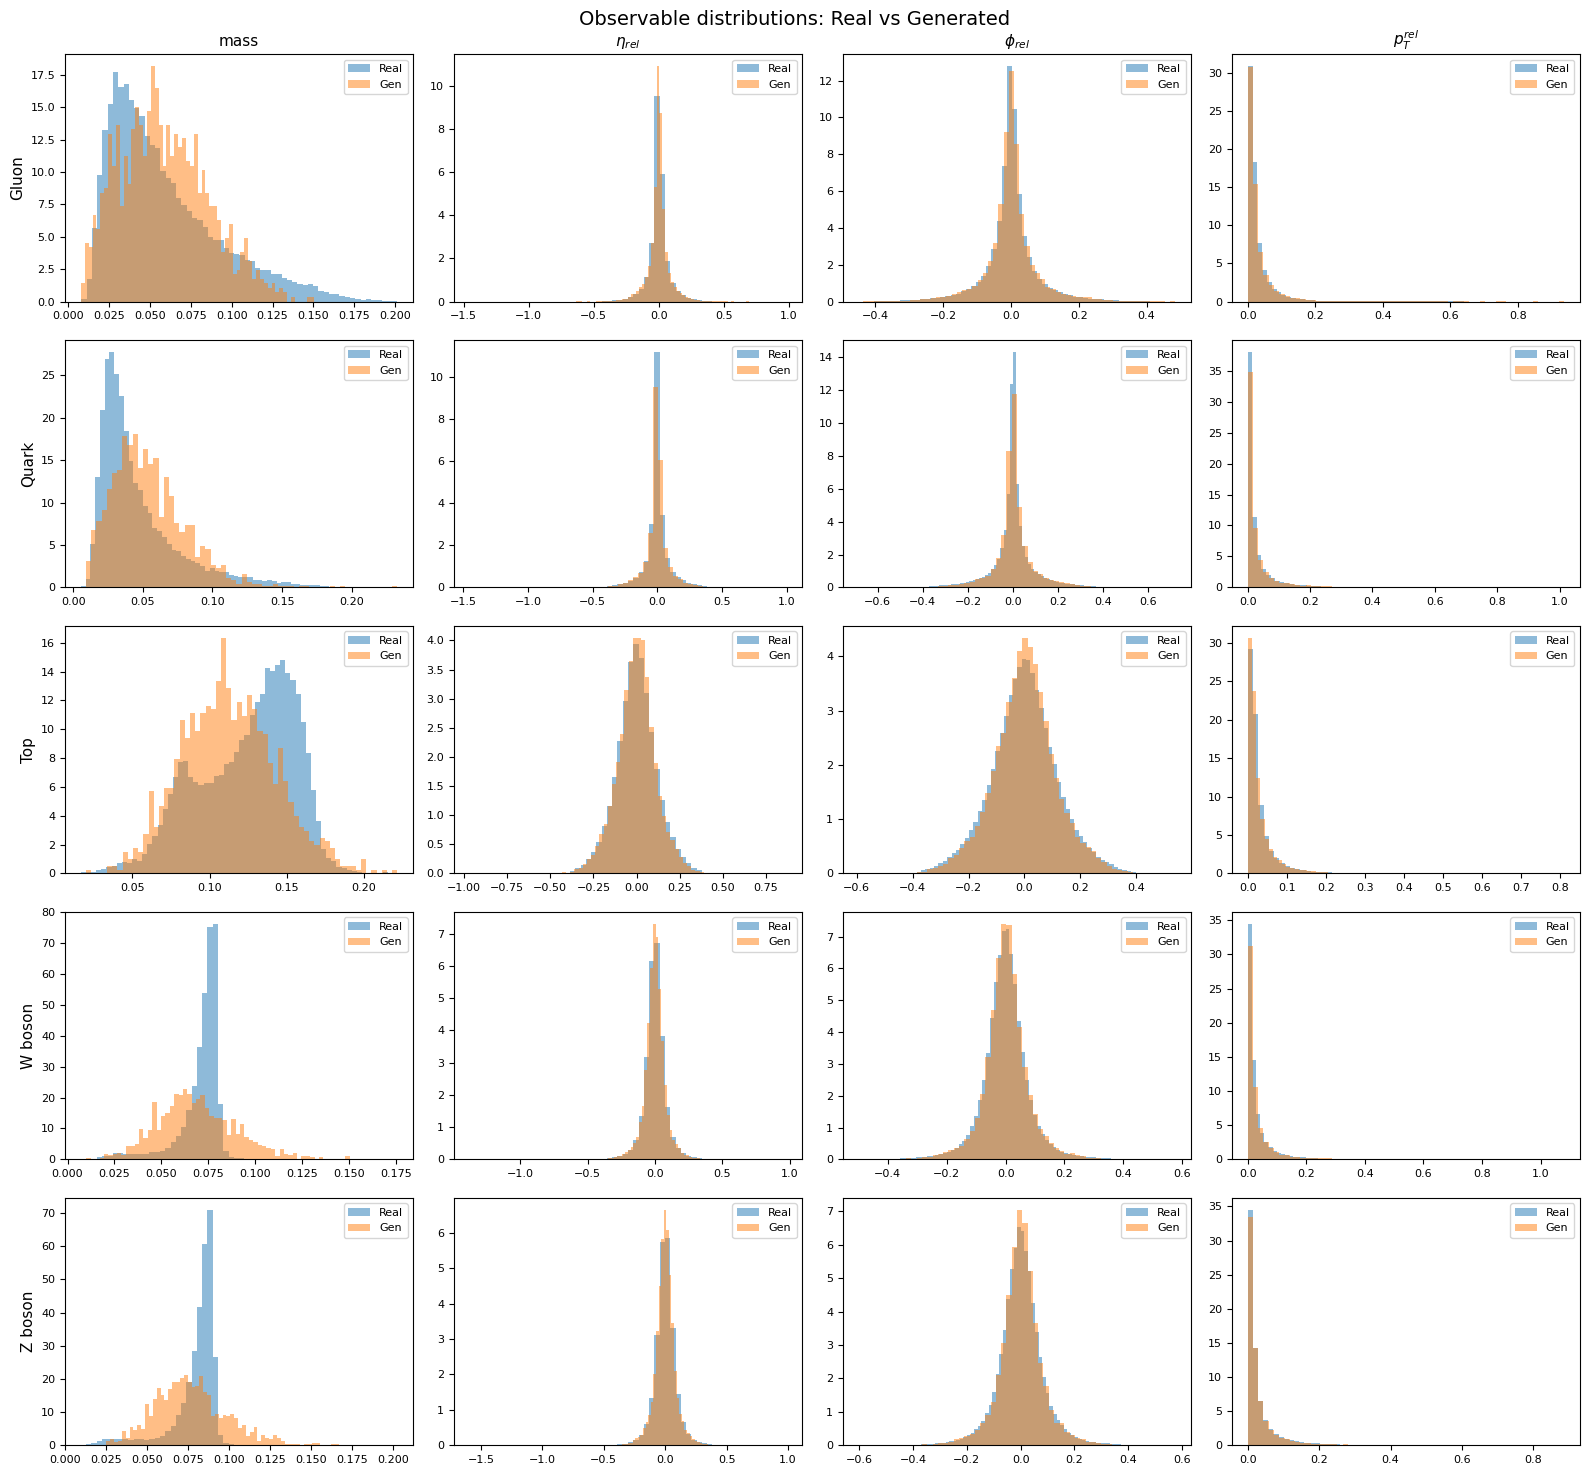

In [13]:
def plot_observables(gen_jets_dict, gen_masks_dict, real_jets_dict, real_masks_dict, save_path=None, dpi=300):
    """Compare generated vs real observable distributions."""
    fig, axes = plt.subplots(N_TYPES, 4, figsize=(16, N_TYPES * 3))
    obs_names = ["mass", "$\\eta_{rel}$", "$\\phi_{rel}$", "$p_T^{rel}$"]
    for row, jt in enumerate(JET_TYPES):
        gen, gen_m = gen_jets_dict[jt], gen_masks_dict[jt]
        real, real_m = real_jets_dict[jt], real_masks_dict[jt]
        axes[row, 0].hist(compute_jet_mass(real, real_m), bins=60, alpha=0.5, density=True, label="Real")
        axes[row, 0].hist(compute_jet_mass(gen, gen_m), bins=60, alpha=0.5, density=True, label="Gen")
        for col, f_idx in enumerate([0, 1, 2]):
            axes[row, col + 1].hist(real[:, :, f_idx][real_m > 0.5], bins=60, alpha=0.5, density=True, label="Real")
            axes[row, col + 1].hist(gen[:, :, f_idx][gen_m > 0.5], bins=60, alpha=0.5, density=True, label="Gen")
        for col in range(4):
            axes[row, col].legend(fontsize=8)
            axes[row, col].tick_params(labelsize=8)
            if row == 0:
                axes[row, col].set_title(obs_names[col], fontsize=11)
        axes[row, 0].set_ylabel(JET_NAMES[jt], fontsize=11)
    plt.suptitle("Observable distributions: Real vs Generated", fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    plt.show()


report_fig_dir = os.path.join("..", "report", "figures") if os.path.basename(os.getcwd()) == "code" else os.path.join("report", "figures")
observables_fig_path = os.path.join(report_fig_dir, "observables_real_vs_generated.png")

plot_observables(gen_jets, gen_masks, val_data, val_masks, save_path=observables_fig_path)

Saved figure to report/figures/eta_phi_real_vs_generated_g.png


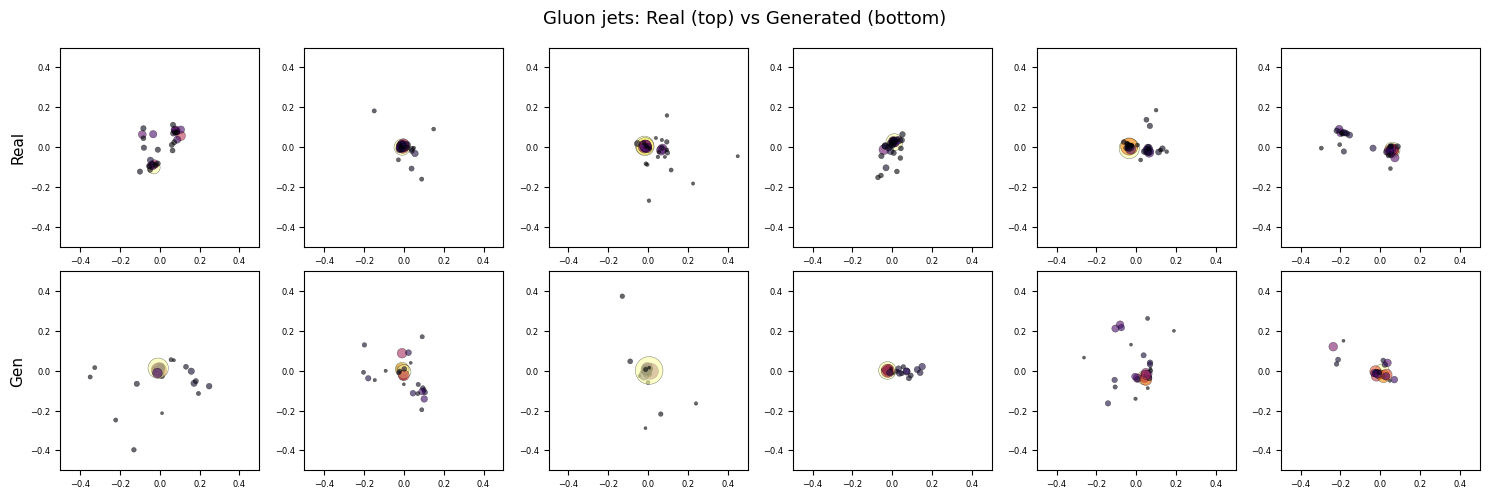

Saved figure to report/figures/eta_phi_real_vs_generated_q.png


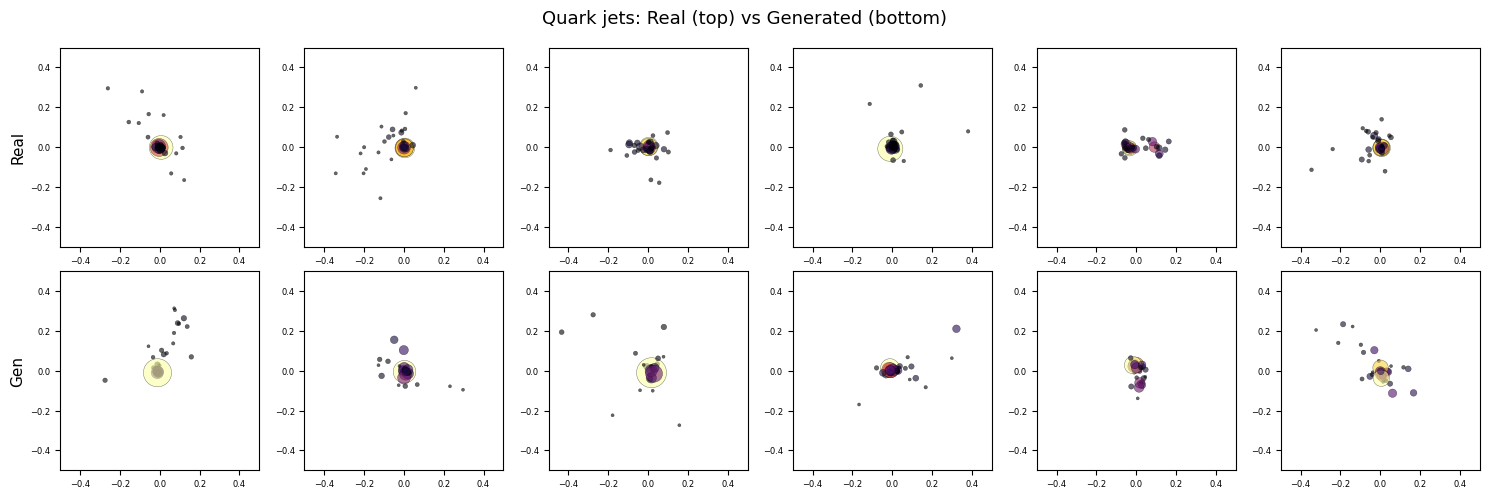

Saved figure to report/figures/eta_phi_real_vs_generated_t.png


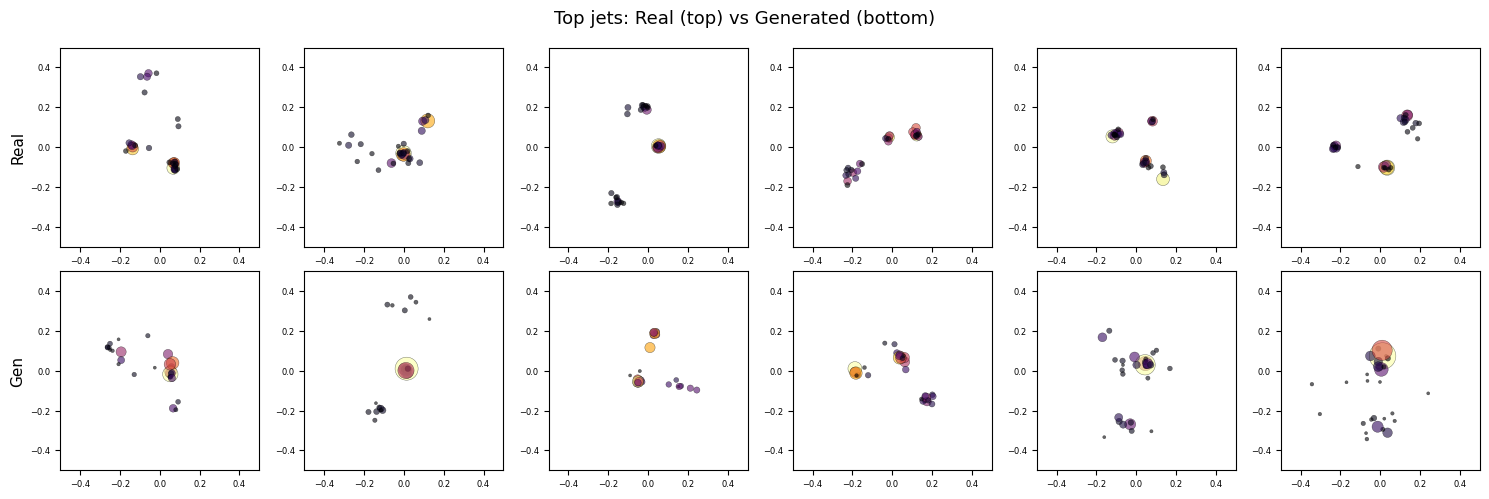

Saved figure to report/figures/eta_phi_real_vs_generated_w.png


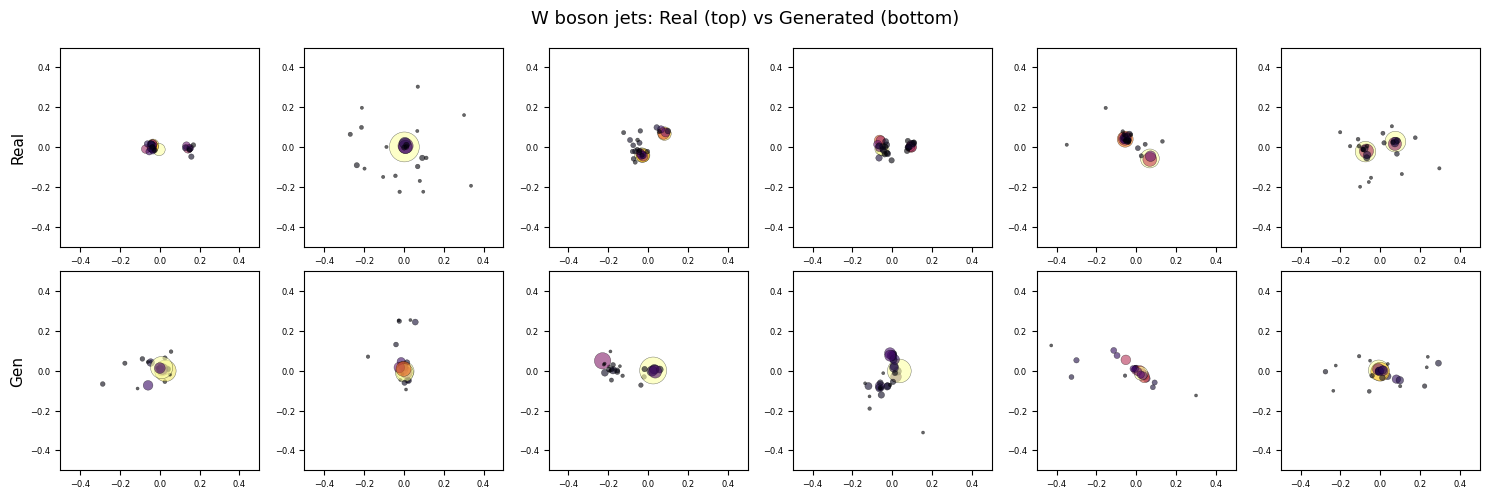

Saved figure to report/figures/eta_phi_real_vs_generated_z.png


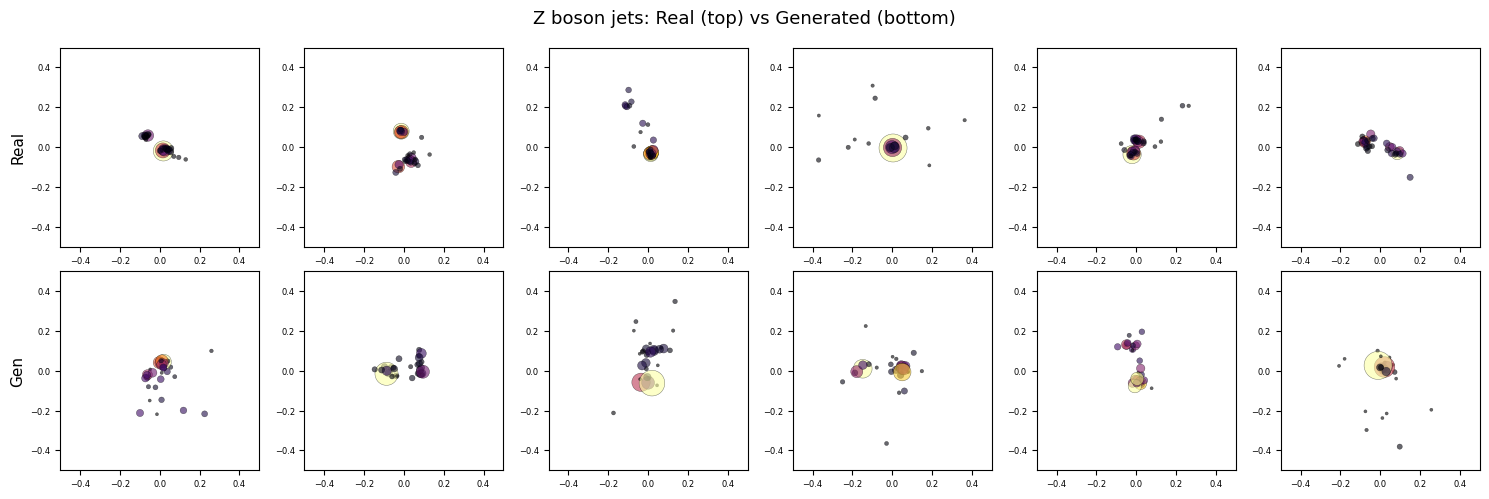

In [14]:
def plot_eta_phi_comparison(real_jets_dict, real_masks_dict, gen_jets_dict, gen_masks_dict, save_dir=None, dpi=300):
    for jt in JET_TYPES:
        fig, axes = plt.subplots(2, 6, figsize=(15, 5))
        for col in range(6):
            for row, (data, masks, label) in enumerate(
                [(real_jets_dict[jt], real_masks_dict[jt], "Real"), (gen_jets_dict[jt], gen_masks_dict[jt], "Gen")]
            ):
                ax = axes[row, col]
                m = masks[col] > 0.5
                eta, phi, pt = data[col, m, 0], data[col, m, 1], data[col, m, 2]
                sizes = 800 * np.clip(pt, 0, None) + 5
                ax.scatter(eta, phi, s=sizes, alpha=0.6, c=pt, cmap="inferno", edgecolors="k", linewidths=0.3)
                ax.set_xlim(-0.5, 0.5)
                ax.set_ylim(-0.5, 0.5)
                ax.set_aspect("equal")
                ax.tick_params(labelsize=6)
                if col == 0:
                    ax.set_ylabel(label, fontsize=11)
        plt.suptitle(f"{JET_NAMES[jt]} jets: Real (top) vs Generated (bottom)", fontsize=13)
        plt.tight_layout()

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"eta_phi_real_vs_generated_{jt}.png")
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
            print(f"Saved figure to {save_path}")

        plt.show()


report_fig_dir = os.path.join("..", "report", "figures") if os.path.basename(os.getcwd()) == "code" else os.path.join("report", "figures")
plot_eta_phi_comparison(val_data, val_masks, gen_jets, gen_masks, save_dir=report_fig_dir)

---
## 4. Save, Validate, and Submit

Deliverables required by `assignment-03.txt`:
- `submission.npz` with keys `{g,q,t,w,z}_jets` and `{g,q,t,w,z}_masks`, each `(2000,30,3)` and `(2000,30)`.
- `model_params.pkl` saved from your best checkpoint.
- `generate.py` that reproduces `submission.npz` from scratch.

Before final push:
1. Run local validation/evaluation on `val.npz`.
2. Confirm generated padded slots remain zero-masked.
3. Ensure notebook model and `generate.py` architecture are identical.

In [15]:
# Save baseline submission and model
save_submission(gen_jets, gen_masks, "submission.npz")
save_model(params, "model_params.pkl")

Saved submission to submission.npz
  g: 2000 jets
  q: 2000 jets
  t: 2000 jets
  w: 2000 jets
  z: 2000 jets
Saved model to model_params.pkl


---
## 5. Report Guidance (What to write)

To align with grading rubric, your report should explicitly include:

- **Approach (~1 page):**
  - What architectural changes were made vs baseline.
  - Why each change is appropriate for masked particle sets / jet physics.

- **Results and analysis (~1 page):**
  - W1 table with per-type and per-observable breakdown.
  - Observable histograms and $(\eta,\phi)$ comparisons.
  - Clear discussion of what worked, what failed, and why.

- **AI collaboration (~0.25 page):**
  - Tools/models used and concrete examples of effective usage.
  - What prompts or workflows were useful or not useful.

Use this notebook’s outputs directly as evidence for those sections.

In [15]:
# Generate, evaluate, and save your best submission
# Keep architecture/sampler in sync with generate.py

import glob
import os
import shutil

# Mount Google Drive and copy submission artifacts + report figures to MyDrive/DS 595
try:
    from google.colab import drive

    drive.mount('/content/drive')
    target_dir = '/content/drive/MyDrive/DS 595'
    os.makedirs(target_dir, exist_ok=True)

    artifacts = ["submission.npz", "model_params.pkl", "generate.py"]
    for fname in artifacts:
        src = os.path.abspath(fname)
        if os.path.exists(src):
            dst = os.path.join(target_dir, os.path.basename(fname))
            shutil.copy2(src, dst)
            print(f"Copied {fname} -> {dst}")
        else:
            print(f"Skipping missing file: {fname}")

    # Copy report figures generated by plotting cells
    figure_dirs = [
        os.path.join("report", "figures"),
        os.path.join("..", "report", "figures"),
        "/content/report/figures",
    ]

    copied_figures = 0
    for fig_dir in figure_dirs:
        fig_dir_abs = os.path.abspath(fig_dir)
        if not os.path.isdir(fig_dir_abs):
            continue

        for fig_path in sorted(glob.glob(os.path.join(fig_dir_abs, "*.png"))):
            dst = os.path.join(target_dir, os.path.basename(fig_path))
            shutil.copy2(fig_path, dst)
            copied_figures += 1
            print(f"Copied figure -> {dst}")

    if copied_figures == 0:
        print("No report figures found to copy. Run the plotting cells first.")
    else:
        print(f"Copied {copied_figures} figure(s) to {target_dir}")

except Exception as e:
    print(f"Drive copy skipped (not in Colab or mount failed): {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied submission.npz -> /content/drive/MyDrive/DS 595/submission.npz
Copied model_params.pkl -> /content/drive/MyDrive/DS 595/model_params.pkl
Skipping missing file: generate.py
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_real_vs_generated_g.png
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_real_vs_generated_q.png
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_real_vs_generated_t.png
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_real_vs_generated_w.png
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_real_vs_generated_z.png
Copied figure -> /content/drive/MyDrive/DS 595/observables_real_vs_generated.png
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_real_vs_generated_g.png
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_real_vs_generated_q.png
Copied figure -> /content/drive/MyDrive/DS 595/eta_phi_rea